# Feature Selection

This notebook will provide the justifcations for feature selection.

# Data Processing

In [1]:
# Packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [3]:
# First 5 rows of dataset
df.show(5)

time,src_user,dest_user,src_comp,dest_comp,auth_type,logon_type,auth_orientation,outcome
i64,str,str,str,str,str,str,str,str
1,"""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C1250""","""C586""","""NTLM""","""Network""","""LogOn""","""Success"""
1,"""ANONYMOUS LOGON@C586""","""ANONYMOUS LOGON@C586""","""C586""","""C586""","""?""","""Network""","""LogOff""","""Success"""
1,"""C101$@DOM1""","""C101$@DOM1""","""C988""","""C988""","""?""","""Network""","""LogOff""","""Success"""
1,"""C1020$@DOM1""","""SYSTEM@C1020""","""C1020""","""C1020""","""Negotiate""","""Service""","""LogOn""","""Success"""
1,"""C1021$@DOM1""","""C1021$@DOM1""","""C1021""","""C625""","""Kerberos""","""Network""","""LogOn""","""Success"""


In [4]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

In [5]:
# Features dataframe
features = (
    df
    .with_columns(
        bucket=pl.col("time") // 3600,
        hour_of_day=(pl.col("time") // 3600) % 24,
        is_failure=(pl.col("outcome") != "Success").cast(pl.Int8),
    )
    .group_by(["src_user", "bucket"])
    .agg(
        hour_of_day=pl.col("hour_of_day").first(),
        n_events=pl.len(),
        n_failures=pl.col("is_failure").sum(),
        failure_ratio=pl.col("is_failure").mean(),
        n_distinct_dest=pl.col("dest_comp").n_unique(),
        n_distinct_src=pl.col("src_comp").n_unique(),
    )
    .collect()
)

In [6]:
features = features.with_columns(
    hod_sin=(2 * np.pi * pl.col("hour_of_day") / 24).sin(),
    hod_cos=(2 * np.pi * pl.col("hour_of_day") / 24).cos(),
)

In [7]:
features.show(5)

src_user,bucket,hour_of_day,n_events,n_failures,failure_ratio,n_distinct_dest,n_distinct_src,hod_sin,hod_cos
str,i64,i64,u64,i64,f64,u64,u64,f64,f64
"""U8120@DOM1""",1165,13,20,0,0.0,3,4,-0.258819,-0.965926
"""U4523@DOM1""",594,18,24,0,0.0,7,5,-1.0,-1.8370e-16
"""U1569@DOM1""",1026,18,4,0,0.0,1,1,-1.0,-1.8370e-16
"""U321@DOM1""",138,18,25,0,0.0,4,6,-1.0,-1.8370e-16
"""U8887@DOM1""",1175,23,25,0,0.0,6,7,-0.258819,0.965926


# Exploratory Data Analysis

In [ ]:
# Number of rows (~ 340 million rows)
df.select(pl.len()).collect().item()

341692445

In [ ]:
# Number of distinct users (30332 distinct users)
features["src_user"].n_unique()


30342

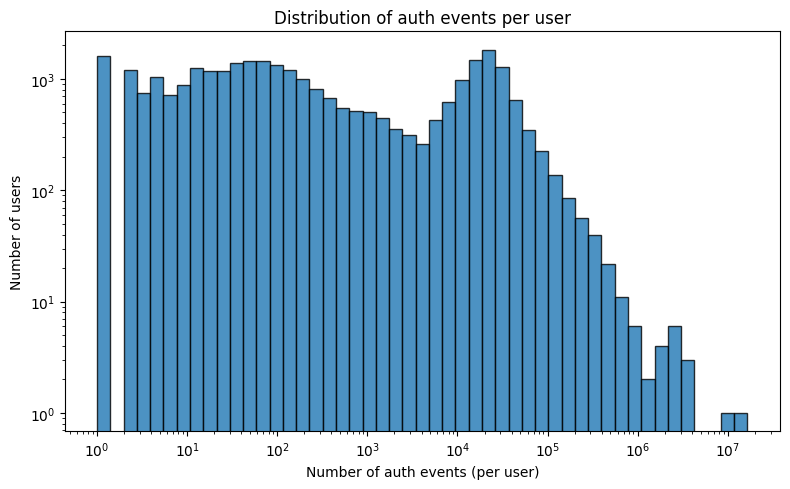

In [ ]:
# Total auth events per user
events_per_user = (
    features
    .group_by("src_user")
    .agg(total_events=pl.col("n_events").sum())
)

counts = events_per_user["total_events"].to_numpy()

# Distribution of auth events per user
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.logspace(np.log10(counts.min()), np.log10(counts.max()), 50)
ax.hist(counts, bins=bins, edgecolor="black", alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")  # optional — drop if you want a linear y-axis
ax.set_xlabel("Number of auth events (per user)")
ax.set_ylabel("Number of users")
ax.set_title("Distribution of auth events per user")
plt.tight_layout()
plt.show()

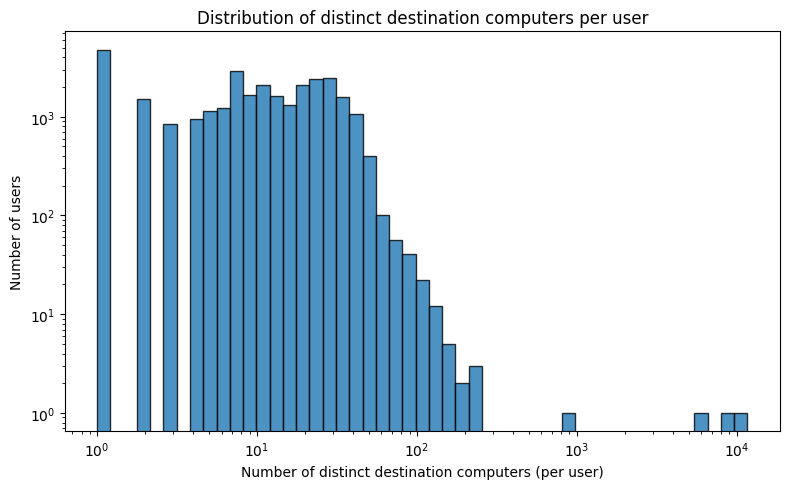

In [36]:
# Distinct destination computers per user
dest_per_user = (
    df
    .group_by("src_user")
    .agg(n_distinct_dest=pl.col("dest_comp").n_unique())
    .collect()
)

counts = dest_per_user["n_distinct_dest"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.logspace(np.log10(counts.min()), np.log10(counts.max()), 50)
ax.hist(counts, bins=bins, edgecolor="black", alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of distinct destination computers (per user)")
ax.set_ylabel("Number of users")
ax.set_title("Distribution of distinct destination computers per user")
plt.tight_layout()
plt.show()

In [37]:
# Distinct source computers per user
dest_per_user = (
    df
    .group_by("src_user")
    .agg(n_distinct_dest=pl.col("src_comp").n_unique())
    .collect()
)

counts = dest_per_user["n_distinct_src"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.logspace(np.log10(counts.min()), np.log10(counts.max()), 50)
ax.hist(counts, bins=bins, edgecolor="black", alpha=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of distinct source computers (per user)")
ax.set_ylabel("Number of users")
ax.set_title("Distribution of distinct source computers per user")
plt.tight_layout()
plt.show()

ColumnNotFoundError: "n_distinct_src" not found

# Clustering 

In [15]:
# Packages
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [16]:
# Extract relevant features
feature_cols = [
    "n_events",
    "failure_ratio",
    "n_distinct_dest",
    "n_distinct_src",
    "hod_sin",
    "hod_cos",
]

X = features.select(feature_cols).to_numpy()

In [17]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# K-Means algorithm
km = KMeans(n_clusters=4, n_init=10, random_state=42)
labels = km.fit_predict(X_scaled)

print(f"Cluster sizes: {np.bincount(labels)}")

Cluster sizes: [3858571 3150823  375625    3170]


In [19]:
features_clustered = features.with_columns(cluster=pl.Series(labels))

(
    features_clustered
    .group_by("cluster")
    .agg(
        size=pl.len(),
        n_events_mean=pl.col("n_events").mean(),
        n_events_median=pl.col("n_events").median(),
        failure_ratio_mean=pl.col("failure_ratio").mean(),
        n_distinct_dest_mean=pl.col("n_distinct_dest").mean(),
        n_distinct_src_mean=pl.col("n_distinct_src").mean(),
        hour_of_day_mean=pl.col("hour_of_day").mean(),
    )
    .sort("cluster")
)

cluster,size,n_events_mean,n_events_median,failure_ratio_mean,n_distinct_dest_mean,n_distinct_src_mean,hour_of_day_mean
i32,u64,f64,f64,f64,f64,f64,f64
0,3858571,51.522271,26.0,0.001188,6.031301,5.130873,10.908511
1,3150823,32.264381,17.0,0.000587,3.746167,4.042306,12.51717
2,375625,23.667647,4.0,0.990546,2.072386,2.00861,11.429636
3,3170,10202.07918,8887.0,0.017738,61.020189,52.913249,11.304732


# References 

https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html

https://scikit-learn.org/stable/modules/clustering.html